## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares MLIP-predicted energies and forces against DFT reference calculations. For each frame in a DFT trajectory, the MLIP takes the DFT-computed structure (atomic positions, cell) as input and performs a single-point evaluation, predicting E and F(r) for that fixed, pre-relaxed geometry. 

The question this tries to answer is: *Given the same structure DFT saw, how close are the MLIP energies and forces?*

Comparison plots are then generated for raw potential energy, relative energy along the trajectory, and adsorption energy (E_ads = E_tot − E_slab − E_gas).

Currently, models used are MACE, MatterSim, and UMA (each run by a script in `model-scripts`).

Note: Although the MLIPs models below are not trained on magnetic field data, magnetically-perturbed DFT data was given and used when constructing the pipeline.


**Directory Setup** \
To run this notebook, make sure your directory structure mimics this:

#### 0. Configuration

In [27]:
import numpy as np
from ase.io import iread, read, write

import subprocess
import os
import time

In [28]:
# construct data structure used to hold user input

# builds a dict describing 1 DFT adsorbate run
# ads: single adsorbate string or two joined like ads1_ads2
# template: path template string with {ads}, {slab}, {config_id} placeholders;
#           define at call site (TEMPLATE in next cell) to handle
#           directory structure variants.

def make_run(ads, slab, config_id, template):
    run_id = f"{ads}_{slab}_{config_id}"
    return {
        "ads":       ads,
        "slab":      slab,
        "config_id": config_id,  # use arbitrary directory numbering to label ads config for now
        "run_id":    run_id,
        "path":      template.format(ads=ads, slab=slab, config_id=config_id),
    }

def make_model(name, python_bin, script_path,  supported_devices=("mps", "cuda", "cpu", "N/A")):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path,
        "supported_devices": list(supported_devices)
    }

In [29]:
# function to set up running model scripts

def conda_python(env_name):
    # resolve env name (eg. 'mlip-mace') to its python binary for the machine this notebook
    # is running on
    out = subprocess.run(['conda', 'env', 'list', '--json'], capture_output=True, text=True)
    import json
    envs = json.loads(out.stdout)['envs']
    for p in envs:
        if p.rstrip('/').endswith(env_name):
            return f"{p}/bin/python"
    raise RuntimeError(f"conda env '{env_name}' not found")

In [30]:
# ================================================
# USER INPUT HERE - edit add new DFT runs & models
# ================================================

# do you want to re-run single-point model evaluations? (note: takes a little time)
RUN_MLIPS = True

# report MLIP calculation wall clock time?
SHOW_TIMING = True

# do you want to read in new DFT data?
#   True:  overwrites files in dft-cache/
#   False: use cached DFT trajectories
WRITE_DFT_DATA = True

# edit: directory path template to dft vaspruns
VASPRUN_PATH_TEMPLATE = "dft-data/{ads}/vasprun.xml"

# RUNS: each entry is (adsorbate name, slab name, path to folder of DFT runs for this adsorbate)
#        for i in range (1, # of runs per adsorbate + 1)
RUNS = (
    [make_run("OCCO_Ag5",     "Ag",      i, VASPRUN_PATH_TEMPLATE) for i in range(0, 1)] +
    [make_run("2CO3_Ag2",     "Ag",      i, VASPRUN_PATH_TEMPLATE) for i in range(0, 1)]
    # [make_run("COCHO",        "YO4PdCu", i, VASPRUN_PATH_TEMPLATE) for i in range(1, 3)] +
    # [make_run("COOH",         "YO4PdCu", i, VASPRUN_PATH_TEMPLATE) for i in range(1, 2)]
)

# MODELS: each entry is (display name, path to that model's python interpreter, runner script)
# each mlip lives in its own conda env to avoid dependency conflicts

MODELS = [
    make_model("NEP89",     conda_python("mlip-nep89"),     "model-scripts/run_nep89.py",     ["cuda", "cpu"]),
    make_model("MACE",      conda_python("mlip-mace"),      "model-scripts/run_mace.py",      ["cuda", "cpu"]),  # mace allegedly supports mps, but you need to fix a bug in the model file first
    make_model("MatterSim", conda_python("mlip-mattersim"), "model-scripts/run_mattersim.py", ["cuda", "cpu"]),
    make_model("UMA",       conda_python("mlip-uma"),       "model-scripts/run_uma.py",       ["cuda", "cpu"]),
]

#### 1. DFT data ingestion

In [31]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (slab reference, gas reference)
def load_frame(path):
    frame = read(path)
    return frame

In [32]:
# run this to read in new DFT data

# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later
MAX_FRAMES = 25  # set sample size here

if WRITE_DFT_DATA:
    from pathlib import Path
    for file in Path("model-scripts/dft-cache/").glob("*"):
        file.unlink()
    for run in RUNS:
        # check num. frames per run sample accordingly
        frames = load_frames(run["path"])
        indices = np.linspace(0, len(frames)-1, min(MAX_FRAMES, len(frames)), dtype=int)
        sampled = [frames[i] for i in indices]
        
        cache_path = Path(f"model-scripts/dft-cache/dft_{run['run_id']}.xyz")
        write(cache_path, sampled)
else:
    print("cell skipped!")

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [33]:
# match best device to run each model on with existing local hardware
# appends 'device' key to MODELS

if RUN_MLIPS:
    import torch

    machine_devices = []
    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        machine_devices.append("mps")
    if torch.cuda.is_available():
        machine_devices.append("cuda")
    machine_devices.append("cpu")

    for m in MODELS:
        if m['supported_devices'] == ["N/A"]:
            m['device'] = "N/A"  # no device concept for this model
            print(f"{m['name']}: device N/A")
        else:
            m['device'] = next(d for d in machine_devices if d in m["supported_devices"])
            print(f"{m['name']}: {m['device']}")
else:
    print("cell skipped!")

NEP89: cpu
MACE: cpu
MatterSim: cpu
UMA: cpu


In [35]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

if RUN_MLIPS:
    env = os.environ.copy()
    env['MPLBACKEND'] = "Agg"

    for model in MODELS:
        for run in RUNS:
            rid = run['run_id']
            in_path = f"model-scripts/dft-cache/dft_{rid}.xyz"
            out_path = f"model-scripts/mlip-results/{model['name'].lower()}_{rid}.npz"
            if not Path(out_path).exists():
                Path(out_path).touch()

            t0 = time.perf_counter()
            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path, model['device']],
                capture_output=True, text=True, env=env
            )
            elapsed = time.perf_counter() - t0

            if r.returncode != 0:
                print(f"-- [{rid}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
                raise RuntimeError("Notebook halted.")
            else:
                msg = f"-- [{rid}] ({model['name']}): success"
                if SHOW_TIMING:
                    msg += f" ({elapsed:.2f}s)"
                print(msg)
else:
    print("cell skipped!")

-- [OCCO_Ag5_Ag_0] (NEP89): success (1.93s)
-- [2CO3_Ag2_Ag_0] (NEP89): success (1.39s)
-- [OCCO_Ag5_Ag_0] (MACE): success (8.91s)
-- [2CO3_Ag2_Ag_0] (MACE): success (8.28s)
-- [OCCO_Ag5_Ag_0] (MatterSim): success (5.51s)
-- [2CO3_Ag2_Ag_0] (MatterSim): success (4.23s)
-- [OCCO_Ag5_Ag_0] (UMA): success (25.59s)
-- [2CO3_Ag2_Ag_0] (UMA): success (25.46s)


In [36]:
# (re)populate RUNS without needing to run models again

def run_paths(run):
    rid = run['run_id']
    root = "model-scripts"
    return {
        'dft_cache': f"{root}/dft-cache/dft_{rid}.xyz",
        'results': {
            m['name'].lower(): f"{root}/mlip-results/{m['name'].lower()}_{rid}.npz"
            for m in MODELS
        },
    }

for run in RUNS:
    run.update(run_paths(run))

#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [37]:
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# group by ads to preserve order
labels = list(dict.fromkeys(r['ads'] for r in RUNS))
runs_by_label = {lbl: [r for r in RUNS if r['ads'] == lbl] for lbl in labels}

config_ids = sorted({run['config_id'] for run in RUNS})
config_colors = {c: plt.cm.tab10(i) for i, c in enumerate(config_ids)}

In [38]:
# read DFT energies from saved XYZ files into each run dict
# slab_energy and gas_energy are single reference values used to compute E_ads later

for run in RUNS:
    frames = read(run['dft_cache'], index=":")
    run['dft'] = {
        "energies": np.array([a.get_potential_energy() for a in frames]),
    }

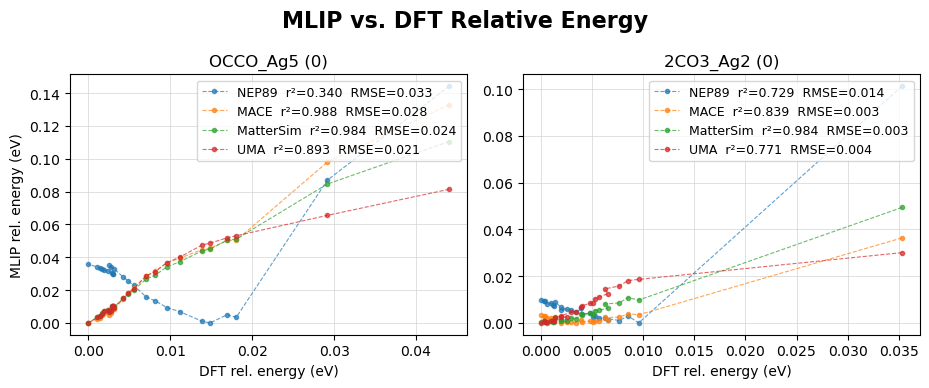

In [ ]:
# --- figure: parity plot, relative energy trajectory by config ---
# MLIP and DFT energies are each relative to their own lowest value

# USER INPUT - select stats displayed on plot:
SHOW_R2   = True
SHOW_RMSE = True

all_runs = [run for lbl in runs_by_label for run in runs_by_label[lbl]]
ncols = min(len(all_runs), 3)
nrows = math.ceil(len(all_runs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.7, nrows*4), dpi=100)
axes = np.array(axes).flatten()
fig.suptitle("MLIP vs. DFT Relative Energy", fontsize=16, fontweight='semibold')

for i, run in enumerate(all_runs):
    ax = axes[i]
    dft_e = run['dft']['energies']
    dft_rel = dft_e - dft_e.min()

    for j, model in enumerate(MODELS):
        name = model['name']
        color = plt.cm.tab10(j)
        mlip_e = np.load(run['results'][name.lower()])['mlip_energies']
        mlip_rel = mlip_e - mlip_e.min()

        stats = [name]
        if SHOW_R2:
            r2 = pearsonr(dft_rel, mlip_rel).statistic ** 2
            stats.append(f"r²={r2:.3f}")
        if SHOW_RMSE:
            rmse = np.sqrt(mean_squared_error(dft_rel, mlip_rel))
            stats.append(f"RMSE={rmse:.3f}")

        ax.plot(dft_rel, mlip_rel, '--o', color=color,
                label="  ".join(stats), markersize=3, lw=0.8, alpha=0.7)

    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(f"{run['ads']} ({run['config_id']})")
    ax.set_xlabel("DFT rel. energy (eV)")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("MLIP rel. energy (eV)")

for ax in axes[len(all_runs):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

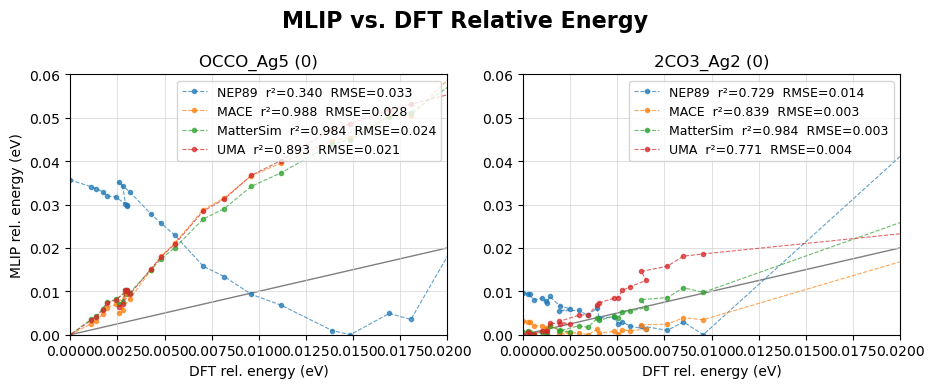

In [41]:
# --- figure: parity plot, relative energy trajectory by config ---
SHOW_R2   = True
SHOW_RMSE = True

# axis limits — set to None to autoscale
XLIM = (0, 0.02)
YLIM = (0, 0.06)

all_runs = [run for lbl in runs_by_label for run in runs_by_label[lbl]]
ncols = min(len(all_runs), 3)
nrows = math.ceil(len(all_runs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.7, nrows*4), dpi=100)
axes = np.array(axes).flatten()
fig.suptitle("MLIP vs. DFT Relative Energy", fontsize=16, fontweight='semibold')

for i, run in enumerate(all_runs):
    ax = axes[i]
    dft_e = run['dft']['energies']
    dft_rel = dft_e - dft_e.min()

    for j, model in enumerate(MODELS):
        name = model['name']
        color = plt.cm.tab10(j)
        mlip_e = np.load(run['results'][name.lower()])['mlip_energies']
        mlip_rel = mlip_e - mlip_e.min()

        stats = [name]
        if SHOW_R2:
            r2 = pearsonr(dft_rel, mlip_rel).statistic ** 2
            stats.append(f"r²={r2:.3f}")
        if SHOW_RMSE:
            rmse = np.sqrt(mean_squared_error(dft_rel, mlip_rel))
            stats.append(f"RMSE={rmse:.3f}")

        ax.plot(dft_rel, mlip_rel, '--o', color=color,
                label="  ".join(stats), markersize=3, lw=0.8, alpha=0.7)

    # parity line, drawn across current axis limits (set after data + lims applied)
    if XLIM: ax.set_xlim(*XLIM)
    if YLIM: ax.set_ylim(*YLIM)
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], '-', color='grey', lw=1, zorder=0)

    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(f"{run['ads']} ({run['config_id']})")
    ax.set_xlabel("DFT rel. energy (eV)")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("MLIP rel. energy (eV)")

for ax in axes[len(all_runs):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

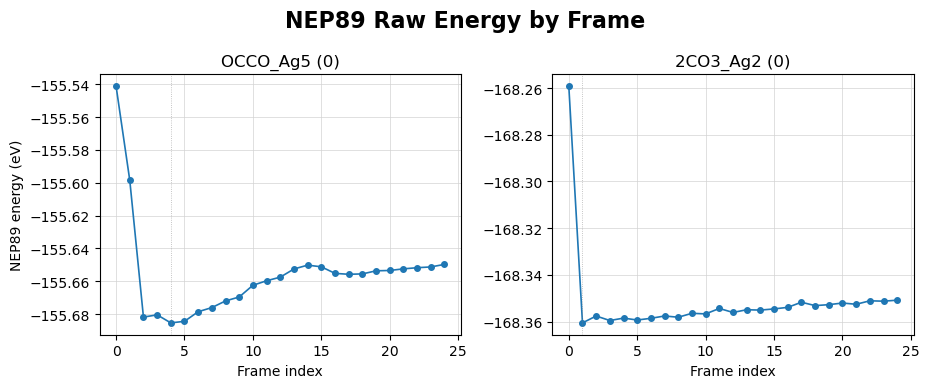

In [43]:
# --- figure: NEP89 raw energy vs. frame index, isolated ---
all_runs = [run for lbl in runs_by_label for run in runs_by_label[lbl]]
ncols = min(len(all_runs), 3)
nrows = math.ceil(len(all_runs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.7, nrows*4), dpi=100)
axes = np.array(axes).flatten()
fig.suptitle("NEP89 Raw Energy by Frame", fontsize=16, fontweight='semibold')

for i, run in enumerate(all_runs):
    ax = axes[i]
    nep89_e = np.load(run['results']['nep89'])['mlip_energies']
    frames = np.arange(len(nep89_e))

    ax.plot(frames, nep89_e, '-o', color=plt.cm.tab10(0),
            markersize=4, lw=1.2)
    ax.axvline(nep89_e.argmin(), color='grey', lw=0.6, ls=':', alpha=0.6)

    ax.set_title(f"{run['ads']} ({run['config_id']})")
    ax.set_xlabel("Frame index")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("NEP89 energy (eV)")

for ax in axes[len(all_runs):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

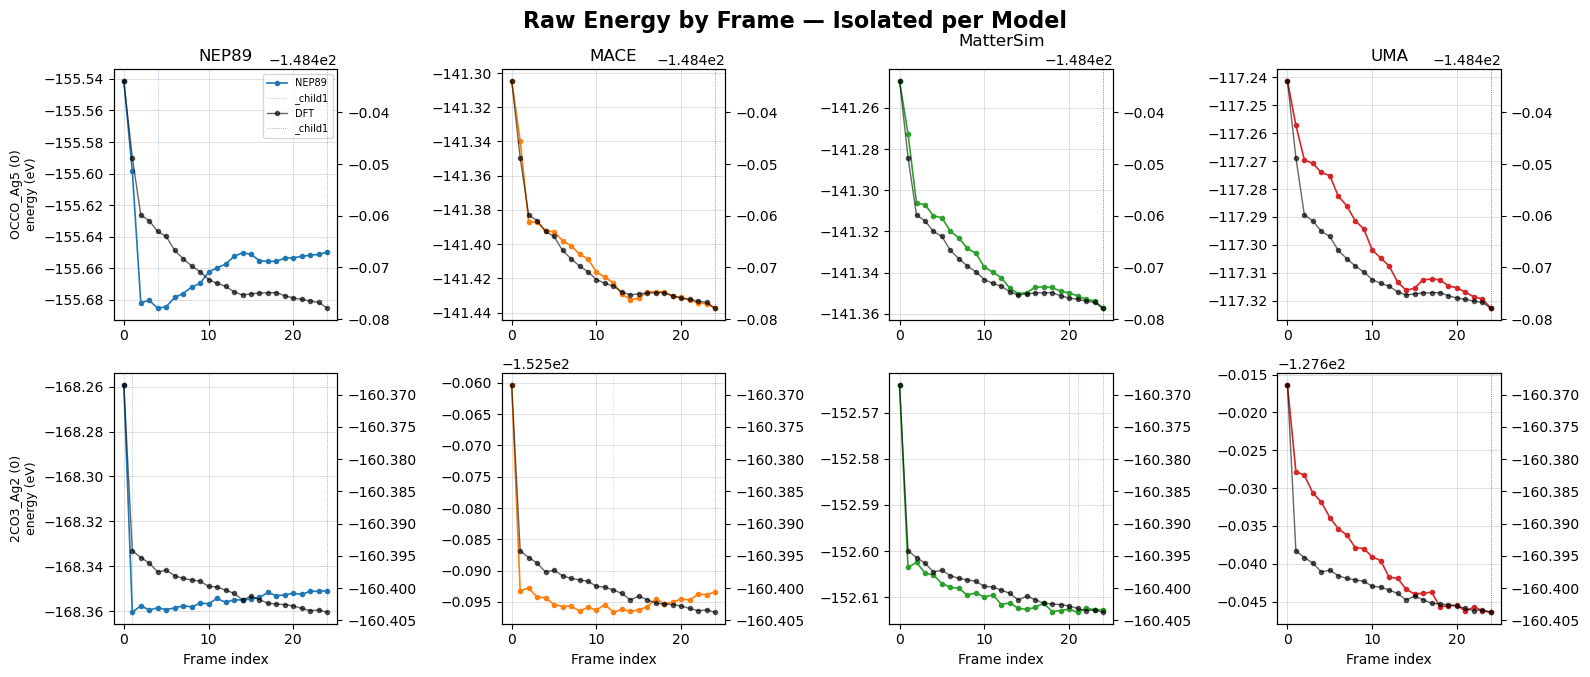

In [44]:
# --- figure: raw energy by frame, isolated per model (own y-scale), DFT overlaid via twin axis ---
all_runs = [run for lbl in runs_by_label for run in runs_by_label[lbl]]
ncols = len(MODELS)

fig, axes = plt.subplots(len(all_runs), ncols, figsize=(ncols*4, len(all_runs)*3.5), dpi=100)
axes = np.atleast_2d(axes)
fig.suptitle("Raw Energy by Frame — Isolated per Model", fontsize=16, fontweight='semibold')

for row, run in enumerate(all_runs):
    dft_e = run['dft']['energies']
    frames = np.arange(len(dft_e))

    for col, model in enumerate(MODELS):
        name = model['name']
        ax = axes[row, col]
        mlip_e = np.load(run['results'][name.lower()])['mlip_energies']

        # MLIP on its own scale
        ax.plot(frames, mlip_e, '-o', color=plt.cm.tab10(col),
                markersize=3, lw=1.2, label=name)
        ax.axvline(mlip_e.argmin(), color=plt.cm.tab10(col), lw=0.6, ls=':', alpha=0.5)

        # DFT overlaid on a twin axis so its shape is comparable, not squashed
        ax2 = ax.twinx()
        ax2.plot(frames, dft_e, '-o', color='black',
                 markersize=3, lw=1.0, alpha=0.6, label="DFT")
        ax2.axvline(dft_e.argmin(), color='black', lw=0.6, ls=':', alpha=0.4)

        if row == 0:
            ax.set_title(name)
        if col == 0:
            ax.set_ylabel(f"{run['ads']} ({run['config_id']})\nenergy (eV)", fontsize=9)
        if row == len(all_runs) - 1:
            ax.set_xlabel("Frame index")
        ax.grid(color='lightgrey', linewidth=0.5)

        if row == 0 and col == 0:
            lines = ax.get_lines() + ax2.get_lines()
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, fontsize=7, loc='best')

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()